开始加载数据...
特征维度: (132, 3), 目标维度: (132, 5)
开始训练简单 Transformer...
Epoch 20/300, Train Loss: 0.5556, Val Loss: 0.2328, Train RMSE: 0.7447, Val RMSE: 0.4825, Train MAE: 0.5957, Val MAE: 0.3854, Train MSE: 0.5556, Val MSE: 0.2328, LR: 0.001000
Epoch 40/300, Train Loss: 0.1134, Val Loss: 0.0489, Train RMSE: 0.3336, Val RMSE: 0.2211, Train MAE: 0.2515, Val MAE: 0.1809, Train MSE: 0.1134, Val MSE: 0.0489, LR: 0.001000
Epoch 60/300, Train Loss: 0.0839, Val Loss: 0.0278, Train RMSE: 0.2893, Val RMSE: 0.1668, Train MAE: 0.2227, Val MAE: 0.1160, Train MSE: 0.0839, Val MSE: 0.0278, LR: 0.001000
Epoch 80/300, Train Loss: 0.0679, Val Loss: 0.0242, Train RMSE: 0.2605, Val RMSE: 0.1555, Train MAE: 0.2053, Val MAE: 0.1256, Train MSE: 0.0679, Val MSE: 0.0242, LR: 0.001000
Epoch 100/300, Train Loss: 0.0815, Val Loss: 0.0151, Train RMSE: 0.2846, Val RMSE: 0.1230, Train MAE: 0.2122, Val MAE: 0.0839, Train MSE: 0.0815, Val MSE: 0.0151, LR: 0.001000
Epoch 120/300, Train Loss: 0.0627, Val Loss: 0.0152, Train RM

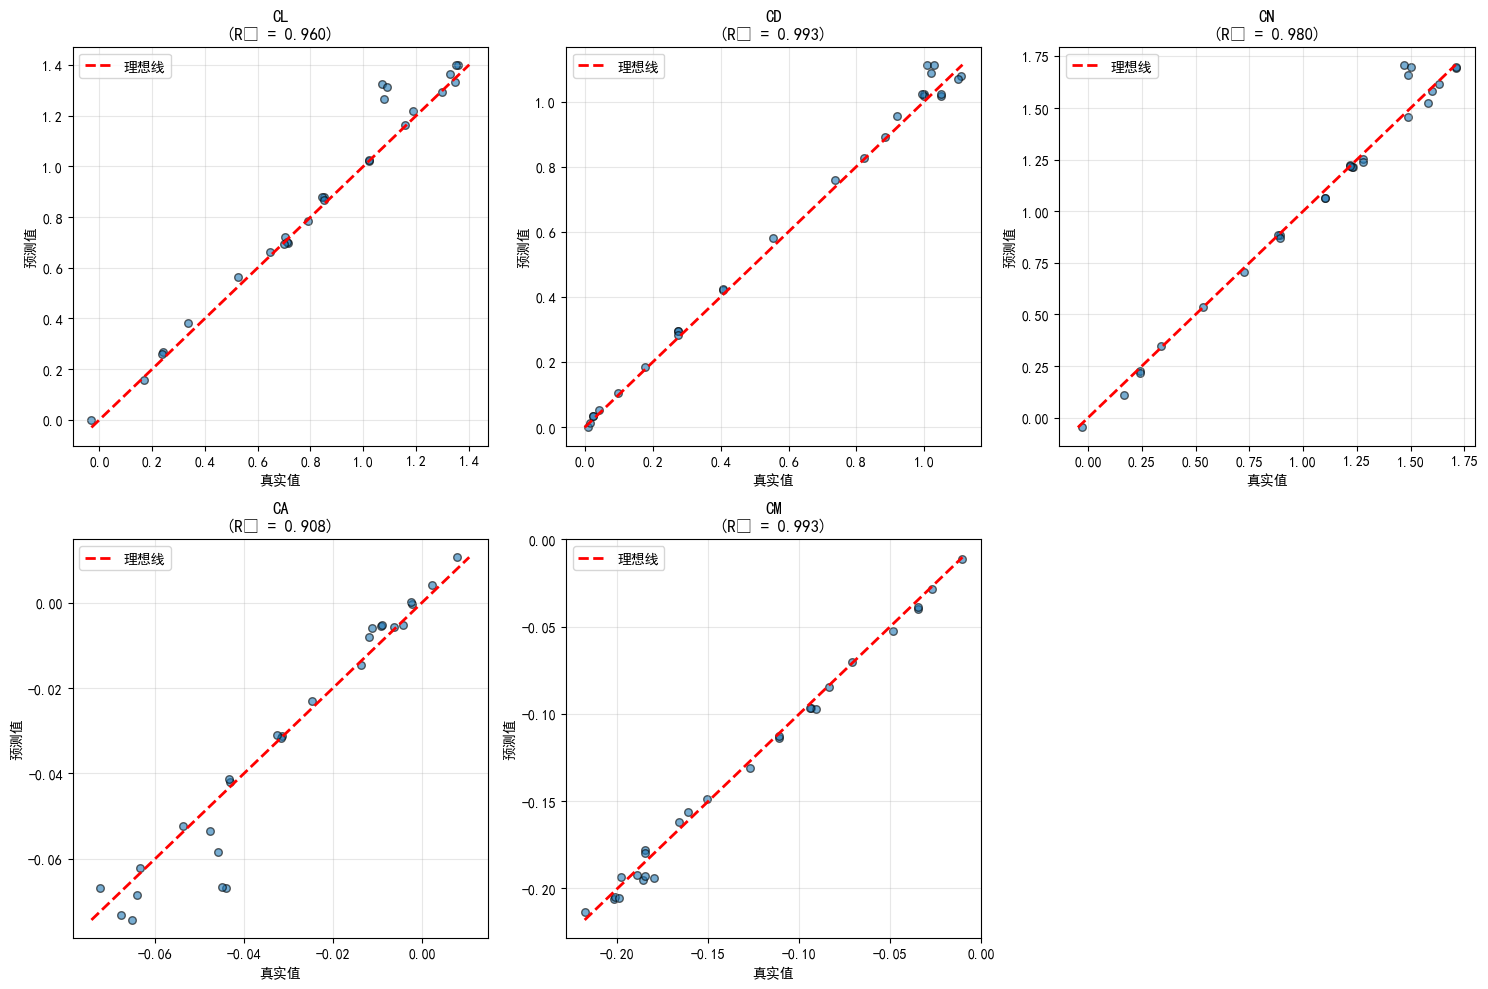

对比图已保存至 simple_transformer_comparison.png

简单 Transformer 对比实验完成！


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

# ==================== 参数定义 ====================
epochs = 300
batch_size = 64
learning_rate = 0.001
weight_decay = 0.0001

# ==================== 数据加载与预处理（与原 FT-Transformer 完全一致） ====================
print("开始加载数据...")
df = pd.read_excel('data_all.xlsx')
feature_columns = ['MA', 'BETA', 'AA']
target_columns = ['CL', 'CD', 'CN', 'CA', 'CM']
X = df[feature_columns].values
y = df[target_columns].values
print(f"特征维度: {X.shape}, 目标维度: {y.shape}")

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

# 转换为 Tensor
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==================== 简单 Transformer 模型 ====================
class SimpleTransformer(nn.Module):
    def __init__(self, num_features, num_outputs, d_model=64, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model
        
        # 将每个特征映射到 d_model 维度（相当于 token 嵌入）
        self.feature_embedding = nn.Linear(1, d_model)
        # 位置编码（可学习）
        self.pos_embedding = nn.Parameter(torch.randn(1, num_features, d_model))
        # Transformer 编码器层
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        # 输出头：对 token 维度取平均后再映射到目标维度
        self.output_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_outputs)
        )
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x):
        # x: (batch_size, num_features)
        batch_size = x.size(0)
        # 将每个特征单独嵌入: (batch, num_features, 1) -> (batch, num_features, d_model)
        x = x.unsqueeze(-1)  # (batch, num_features, 1)
        x = self.feature_embedding(x)  # (batch, num_features, d_model)
        # 添加位置编码
        x = x + self.pos_embedding
        x = self.dropout(x)
        # Transformer 编码
        x = self.transformer(x)  # (batch, num_features, d_model)
        # 对 token 维度取平均池化
        x = x.mean(dim=1)  # (batch, d_model)
        # 输出头
        out = self.output_head(x)
        return out

# ==================== 损失函数与训练准备 ====================
def combined_loss(y_true, y_pred):
    mse = nn.MSELoss()(y_true, y_pred)
    mae = nn.L1Loss()(y_true, y_pred)
    return mse 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleTransformer(
    num_features=X_train.shape[1],
    num_outputs=5,
    d_model=64,          # 比 FT-Transformer 的 128 小，保持轻量
    nhead=4,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-8, verbose=True)

# ==================== 训练函数（与原代码一致） ====================
def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=epochs):
    train_losses = []
    val_losses = []
    train_rmses = []
    val_rmses = []
    train_maes = []
    val_maes = []
    learning_rates = []
    best_val_rmse = float('inf')
    patience = 3000
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_rmse = 0.0
        train_mae = 0.0
        train_mse = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = combined_loss(batch_y, y_pred)
            mse = nn.MSELoss()(y_pred, batch_y)
            rmse = torch.sqrt(mse)
            mae = nn.L1Loss()(y_pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            train_rmse += rmse.item()
            train_mae += mae.item()
            train_mse += mse.item()

        model.eval()
        val_loss = 0.0
        val_rmse = 0.0
        val_mae = 0.0
        val_mse = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = combined_loss(batch_y, outputs)
                mse = nn.MSELoss()(outputs, batch_y)
                rmse = torch.sqrt(mse)
                mae = nn.L1Loss()(outputs, batch_y)
                val_loss += loss.item()
                val_rmse += rmse.item()
                val_mae += mae.item()
                val_mse += mse.item()

        train_loss /= len(train_loader)
        train_rmse /= len(train_loader)
        train_mae /= len(train_loader)
        train_mse /= len(train_loader)
        val_loss /= len(val_loader)
        val_rmse /= len(val_loader)
        val_mae /= len(val_loader)
        val_mse /= len(val_loader)

        scheduler.step(val_rmse)
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)
        train_maes.append(train_mae)
        val_maes.append(val_mae)
        learning_rates.append(current_lr)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), 'best_simple_transformer.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print('早停触发')
            break

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}, '
                  f'Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}, '
                  f'Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}, LR: {current_lr:.6f}')

    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_rmses': train_rmses,
        'val_rmses': val_rmses,
        'train_maes': train_maes,
        'val_maes': val_maes,
        'learning_rates': learning_rates,
    }
    model.load_state_dict(torch.load('best_simple_transformer.pth'))
    return history

# ==================== 评估函数（与原 FT-Transformer 完全一致） ====================
def evaluate_model(model, data_loader, scaler_y, device):
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            all_preds.append(outputs.cpu().numpy())
            all_trues.append(batch_y.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_trues = np.vstack(all_trues)

    all_preds_orig = scaler_y.inverse_transform(all_preds)
    all_trues_orig = scaler_y.inverse_transform(all_trues)

    total_mse = mean_squared_error(all_trues_orig, all_preds_orig)
    total_rmse = np.sqrt(total_mse)
    total_mae = mean_absolute_error(all_trues_orig, all_preds_orig)
    total_r2 = r2_score(all_trues_orig, all_preds_orig)
    mse_loss = np.mean((all_trues_orig - all_preds_orig) ** 2)
    mae_loss = np.mean(np.abs(all_trues_orig - all_preds_orig))
    total_combined = mse_loss + 0.33 * mae_loss

    n_outputs = all_trues_orig.shape[1]
    component_metrics = {}
    for i in range(n_outputs):
        y_true_i = all_trues_orig[:, i]
        y_pred_i = all_preds_orig[:, i]
        rmse_i = np.sqrt(mean_squared_error(y_true_i, y_pred_i))
        mae_i = mean_absolute_error(y_true_i, y_pred_i)
        r2_i = r2_score(y_true_i, y_pred_i)
        epsilon = 1e-8
        mre_i = np.mean(np.abs((y_true_i - y_pred_i) / (np.abs(y_true_i) + epsilon)))
        component_metrics[i] = {'RMSE': rmse_i, 'MAE': mae_i, 'R2': r2_i, 'MRE': mre_i}

    overall_metrics = {
        'MSE': total_mse,
        'RMSE': total_rmse,
        'MAE': total_mae,
        'R2': total_r2,
        'Combined_Loss': total_combined
    }
    return overall_metrics, component_metrics, (all_trues_orig, all_preds_orig)

# ==================== 训练 ====================
print('开始训练简单 Transformer...')
history = train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=epochs)
print('训练完成，加载最佳模型')

# ==================== 评估 ====================
print("\n===== 测试集评估结果（原始尺度） =====")
test_overall, test_component, (test_true, test_pred) = evaluate_model(model, test_loader, scaler_y, device)

print(f"总体指标: MSE={test_overall['MSE']:.4f}, RMSE={test_overall['RMSE']:.4f}, MAE={test_overall['MAE']:.4f}, R2={test_overall['R2']:.4f}, Combined={test_overall['Combined_Loss']:.4f}")

print("\n各分量详细指标:")
for i, name in enumerate(target_columns):
    m = test_component[i]
    print(f"{name}: RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, R2={m['R2']:.4f}, MRE={m['MRE']:.4%}")

print("\n===== 训练集评估结果 =====")
train_overall, _, _ = evaluate_model(model, train_loader, scaler_y, device)
print(f"总体RMSE={train_overall['RMSE']:.4f}, R2={train_overall['R2']:.4f}")

print("\n===== 验证集评估结果 =====")
val_overall, _, _ = evaluate_model(model, val_loader, scaler_y, device)
print(f"总体RMSE={val_overall['RMSE']:.4f}, R2={val_overall['R2']:.4f}")

# ==================== 可视化 ====================
def plot_true_vs_pred(true, pred, target_names, component_metrics, save_path='simple_transformer_comparison.png'):
    n = len(target_names)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for i, name in enumerate(target_names):
        ax = axes[i]
        ax.scatter(true[:, i], pred[:, i], alpha=0.6, edgecolors='k', s=30)
        min_val = min(true[:, i].min(), pred[:, i].min())
        max_val = max(true[:, i].max(), pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='理想线')
        ax.set_xlabel('真实值')
        ax.set_ylabel('预测值')
        ax.set_title(f'{name}\n(R² = {component_metrics[i]["R2"]:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    if n < len(axes):
        axes[-1].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"对比图已保存至 {save_path}")

plot_true_vs_pred(test_true, test_pred, target_columns, test_component, save_path='simple_transformer_comparison.png')

print("\n简单 Transformer 对比实验完成！")